In [2]:
import os
import sys

import logging

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse
import matplotlib.pyplot as plt
# import pynvml
import time

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# jax.config.update('jax_disable_jit', True)

# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None

In [3]:
imerg_era5_dir = '/Datastorage/saptarishi.dhanuka_asp25/'
file_name = 'era5_imerg_20150701-2015_india_full_globe.nc'
imerg_test = xr.open_dataset(os.path.join(imerg_era5_dir, file_name))
imerg_test

<xarray.Dataset> Size: 44GB
Dimensions:                  (time: 736, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 6kB 2015-07-01 ... 2015-12...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 192MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 192MB ...
    2m_temperature           (time, latitude, longitude) float32 192MB ...
    geopotential             (time, level, latitude, longitude) float32 7GB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB ...
    land_sea_mask            (latitude, longitude) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 7GB ...
    temperature              (time, level, latitude, longitude) float32 7GB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 192MB ...
    u_component_of_wind      (time, level, latitude, longitude) float32 7GB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 7GB ...
    vertical_velocity        (time, level, latitude, longitude) float32 7GB ...

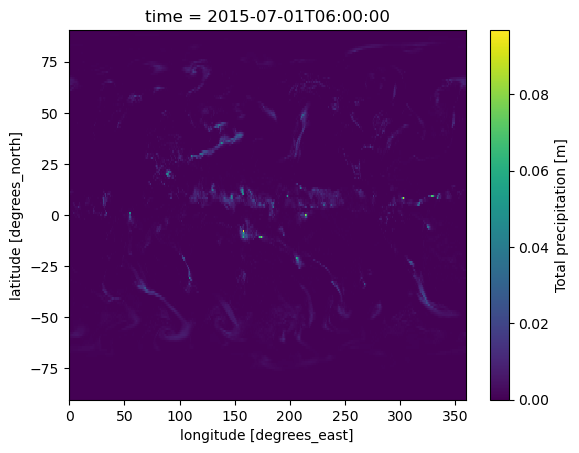

In [ ]:
imerg_test.isel(time=1)['total_precipitation_6hr'].plot()

In [ ]:
inits = 4
global mean_by_level
global stddev_by_level
global diffs_stddev_by_level
global model_config
global task_config
global params
global state

log_file = f"loggers/printing_logs{current_date}.log"
logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger()
logger.info("Starting the script")

model_levels = 13
model_resolution = 1.0
if model_levels == 37:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_37.npz'
        
elif model_resolution == 0.25:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_13.npz'
    
    with open(f'/Datastorage/saptarishi.dhanuka_asp25/era5_data/graphcast_dataset_source-era5_date-2022-01-01_res-{args.model_resolution}_levels-13_steps-12.nc', 'rb') as f:
        logger.info("Loading Dataset")
        tik = datetime.now()
        training_trial_batch = xr.load_dataset(f).compute()
        tok = datetime.now()
        logger.info(f"Dataset loaded in {tok - tik}")

else:

    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'
    dataset_name = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/arco_era5_1.0_formatted.nc"

    arco = imerg_test
    
    old_lats = arco['latitude'].values
    old_lons = arco['longitude'].values
    new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
    new_lats = np.flip(new_lats)
    new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
    if (imerg_test['latitude'].values[1] - imerg_test['latitude'].values[0]) != 1:
        print("Starting interpolation")
        arco = arco.interp({'latitude': new_lats, 'longitude': new_lons}, 
                                method='linear',
                                kwargs={'fill_value': None})
        
        print("Interpolation done")
    
    input_vars = ['10m_u_component_of_wind',
                'geopotential_at_surface',
                '10m_v_component_of_wind',
                'specific_humidity',
                'land_sea_mask',
                'vertical_velocity',
                'geopotential',
                'v_component_of_wind',
                'temperature',
                'total_precipitation_6hr',
                'mean_sea_level_pressure',
                '2m_temperature',
                'u_component_of_wind']
    
    # arco = arco.drop_vars(['toa_incident_solar_radiation',
    # 'year_progress_sin',
    # 'year_progress_cos',
    # 'day_progress_sin',
    # 'day_progress_cos','cos_latitude',
    # 'cos_longitude','sin_longitude'])

    # arco = arco.rename({'total_precipitation': 'total_precipitation_6hr'})

    print("Renaming variables")

    arco = arco.expand_dims(batch=1)
    arco = arco.rename({'latitude': 'lat', 'longitude': 'lon'})

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset

    print("Assigning coordinates")
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )

    logger.info("Coordinates first time")
    logger.info(arco1)
    logger.info("\n")
    logger.info(arco1.coords)
    logger.info("\n")


    # arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    # arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    print(f"Coordinates after reassigning: {arco1.coords}\n")


    logger.info(arco1.nbytes)

    select_time = arco1.isel(time=slice(0, 240))
    tik = datetime.now()

    select_time_eval = arco1

    eval_trial_batch = select_time_eval.load()



    select_time_evals = [imerg_test.isel(time=slice(i*26, i*28+30)) for i in range(inits)]


    print(f"Eval batch first time: {eval_trial_batch.time.values}")
    # training_trial_batch = select_time.load()

    tok = datetime.now()
    # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    logger.info("Training batch time")
    # logger.info(training_trial_batch.coords)
    logger.info(f"Dataset loaded in {tok - tik}")

    # with open("/Datastorage/saptarishi.dhanuka_asp25/era5_data/dataset_source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc", 'rb') as f:
    #     print("Loading Dataset")
    #     tik = datetime.now()
    #     training_trial_batch = xr.load_dataset(f).compute()
    #     # training_trial_batch = training_trial_batch.isel(time=slice(0, 12))
    #     # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    #     print("Training batch time")
    #     print(training_trial_batch.datetime)
    #     tok = datetime.now()
    #     print(f"Dataset loaded in {tok - tik}")


with open(filename, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params


with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()


state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
logger.info(model_config)
logger.info(task_config)
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
    'params': ckpt.params,
    'state': {},
    'model_config': ckpt.model_config,
    'task_config': ckpt.task_config,
    'mean_by_level': mean_by_level,
    'stddev_by_level': stddev_by_level,
    'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )
    return predictions
# TODO: Add data validation at various steps

Renaming variables
Assigning coordinates
Coordinates after reassigning: Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * level     (level) int64 296B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 6kB 2015-07-01 ... 2015-12-31T18:0...
  * time      (time) timedelta64[ns] 6kB 0 days 00:00:00 ... 183 days 18:00:00

Eval batch first time: [                0    21600000000000    43200000000000    64800000000000
    86400000000000   108000000000000   129600000000000   151200000000000
   172800000000000   194400000000000   216000000000000   237600000000000
   259200000000000   280800000000000   302400000000000   324000000000000
   345600000000000   367200000000000   388800000000000   410400000000000
   432000000000000   453600000000000   475200000000000   496800000000000
   518400000000000   540000000000000   561600000000000

In [ ]:
task_config = ckpt.task_config
task_config

TaskConfig(input_variables=('2m_temperature', 'mean_sea_level_pressure', '10m_v_component_of_wind', '10m_u_component_of_wind', 'total_precipitation_6hr', 'temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'specific_humidity', 'toa_incident_solar_radiation', 'year_progress_sin', 'year_progress_cos', 'day_progress_sin', 'day_progress_cos', 'geopotential_at_surface', 'land_sea_mask'), target_variables=('2m_temperature', 'mean_sea_level_pressure', '10m_v_component_of_wind', '10m_u_component_of_wind', 'total_precipitation_6hr', 'temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'specific_humidity'), forcing_variables=('toa_incident_solar_radiation', 'year_progress_sin', 'year_progress_cos', 'day_progress_sin', 'day_progress_cos'), pressure_levels=(50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000), input_duration='12h')

In [ ]:
select_time_evals[-1]

<xarray.Dataset> Size: 2GB
Dimensions:                  (time: 36, latitude: 181, longitude: 360, level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 288B 2015-07-20T12:00:00 ....
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 9MB 0.6877 ....
    10m_v_component_of_wind  (time, latitude, longitude) float32 9MB -0.4563 ...
    2m_temperature           (time, latitude, longitude) float32 9MB 231.9 .....
    geopotential             (time, level, latitude, longitude) float32 347MB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB 2.735e+04 .....
    land_sea_mask            (latitude, longitude) float32 261kB 1.0 1.0 ... 0.0
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 347MB ...
    temperature              (time, level, latitude, longitude) float32 347MB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 9MB 0.000303...
    u_component_of_wind      (time, level, latitude, longitude) float32 347MB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 347MB ...
    vertical_velocity        (time, level, latitude, longitude) float32 347MB ...

In [ ]:
new_params_path = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz"
f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params

In [ ]:
select_time_evals_copy = select_time_evals.copy()
df_test = select_time_evals_copy[0].copy()
df_test

<xarray.Dataset> Size: 2GB
Dimensions:                  (time: 30, latitude: 181, longitude: 360, level: 37)
Coordinates:
  * latitude                 (latitude) float32 724B -90.0 -89.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                     (time) datetime64[ns] 240B 2015-07-01 ... 2015-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 8MB 0.1108 ....
    10m_v_component_of_wind  (time, latitude, longitude) float32 8MB -0.206 ....
    2m_temperature           (time, latitude, longitude) float32 8MB 209.7 .....
    geopotential             (time, level, latitude, longitude) float32 289MB ...
    geopotential_at_surface  (latitude, longitude) float32 261kB 2.735e+04 .....
    land_sea_mask            (latitude, longitude) float32 261kB 1.0 1.0 ... 0.0
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 289MB ...
    temperature              (time, level, latitude, longitude) float32 289MB ...
    total_precipitation_6hr  (time, latitude, longitude) float32 8MB 1.805e-0...
    u_component_of_wind      (time, level, latitude, longitude) float32 289MB ...
    v_component_of_wind      (time, level, latitude, longitude) float32 289MB ...
    vertical_velocity        (time, level, latitude, longitude) float32 289MB ...

In [ ]:

for i in tqdm(range(inits)):
    select_time_evals_copy[i]['total_precipitation_6hr'] = select_time_evals_copy[i]['total_precipitation_6hr'].astype('float32')
    arco = select_time_evals_copy[i]
    arco = arco.expand_dims(batch=1)

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )


    # arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    # arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    select_time_evals_copy[i] = arco1

100%|██████████| 4/4 [00:00<00:00, 146.74it/s]


In [ ]:
# for each xarray dataset in select_time_evals_copy, rename latitude and longitude to lat and lon
for i in range(inits):
    select_time_evals_copy[i] = select_time_evals_copy[i].rename({'latitude': 'lat', 'longitude': 'lon'})
    

In [ ]:
for i in tqdm(range(inits)):
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    select_time_evals_copy[i].load(), target_lead_times=slice("6h", "168h"),
    **dataclasses.asdict(task_config))

    assert select_time_evals_copy[i].sizes["time"] >= 3

    logger.info(f"Eval batch time dimensions: {eval_trial_batch.sizes['time']}")

    task_config_dict =  dataclasses.asdict(task_config)
    # task_config_dict.pop('input_duration')

    print("Eval Inputs:   ", eval_inputs.dims.mapping)
    print("Eval Targets:  ", eval_targets.dims.mapping)
    print("Eval Forcings: ", eval_forcings.dims.mapping)

    targets_template = eval_targets * np.nan

    print("Running old params")
    predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

    print("Predictions Old: ", predictions_old.dims.mapping)


    print("Running new params")

    predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
    print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


    predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_{i}_imerg4.nc")
    predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_{i}_imerg4.nc")

  0%|          | 0/4 [00:00<?, ?it/s]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


 25%|██▌       | 1/4 [01:36<04:50, 96.80s/it]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


 50%|█████     | 2/4 [03:02<03:00, 90.20s/it]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


 75%|███████▌  | 3/4 [04:30<01:29, 89.32s/it]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


100%|██████████| 4/4 [05:59<00:00, 89.81s/it]


In [ ]:
predictions_old

<xarray.Dataset> Size: 606MB
Dimensions:                  (time: 28, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 7MB xarray_jax.J...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 7MB xarray_jax.J...
    2m_temperature           (time, batch, lat, lon) float32 7MB xarray_jax.J...
    geopotential             (time, batch, level, lat, lon) float32 95MB xarr...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 7MB xarray_jax.J...
    specific_humidity        (time, batch, level, lat, lon) float32 95MB xarr...
    temperature              (time, batch, level, lat, lon) float32 95MB xarr...
    total_precipitation_6hr  (time, batch, lat, lon) float32 7MB xarray_jax.J...
    u_component_of_wind      (time, batch, level, lat, lon) float32 95MB xarr...
    v_component_of_wind      (time, batch, level, lat, lon) float32 95MB xarr...
    vertical_velocity        (time, batch, level, lat, lon) float32 95MB xarr...

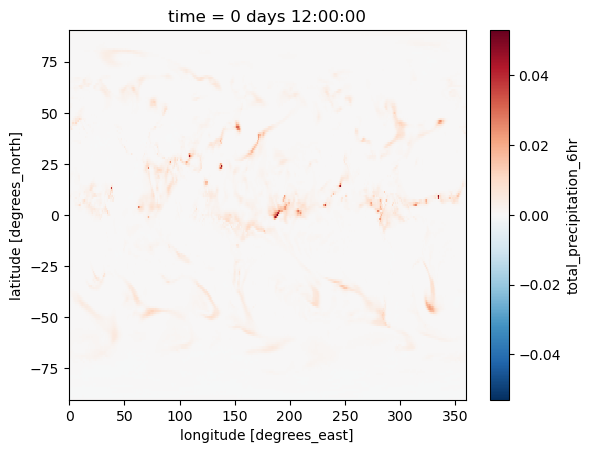

In [ ]:
predictions_old.isel(time=1)['total_precipitation_6hr'].plot()

In [ ]:
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2015/hres_2015_7_22_ppt.grib')
hres

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 103MB
Dimensions:     (step: 8, values: 2140702)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B ...
    latitude    (values) float64 17MB ...
    longitude   (values) float64 17MB ...
    valid_time  (step) datetime64[ns] 64B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 69MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-16T21:37 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
regridded_hres = regrid_hres_fine_to_coarse(hres, variable='tp', coarse_resolution=1.0)
regridded_hres

Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


<xarray.DataArray 'tp' (step: 8, lat: 181, lon: 360)> Size: 2MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[1.04904175e-05, 1.04904175e-05, 1.04904175e-05, ...,
         1.04904175e-05, 1.04904175e-05, 1.04904175e-05],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
        [8.77380371e-05, 8.77380371e-05, 8.77380371e-05, ...,
         5.34057617e-05, 8.77380371e-05, 8.77380371e-05],
        [7.62939453e-05, 7.62939453e-05, 7.62939453e-05, ...,
         6.10351562e-05, 7.62939453e-05, 7.62939453e-05],
        [1.10626221e-04, 1.10626221e-04, 1.10626221e-04, ...,
         1.10626221e-04, 1.10626221e-04, 1.10626221e-04]],

       [[4.57763672e-05, 4.57763672e-05, 4.57763672e-05, ...,
         4.57763672e-05, 4.57763672e-05, 4.57763672e-05],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [9.53674316e-05, 9.53674316e-05, 9.53674316e-05, ...,
         6.10351562e-05, 9.53674316e-05, 9.53674316e-05],
        [8.77380371e-05, 8.77380371e-05, 8.77380371e-05, ...,
         7.24792480e-05, 8.77380371e-05, 8.77380371e-05],
        [1.18255615e-04, 1.18255615e-04, 1.18255615e-04, ...,
         1.18255615e-04, 1.18255615e-04, 1.18255615e-04]]], dtype=float32)
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2015-07-15
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2015-07-15 ... 2015-07-15T07:00:00
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             2140702
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d

In [ ]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
select_time_evals_copy[3].load(), target_lead_times=slice("6h", "168h"),
**dataclasses.asdict(task_config))

In [ ]:
eval_targets

<xarray.Dataset> Size: 606MB
Dimensions:                  (batch: 1, time: 28, lat: 181, lon: 360, level: 13)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
Dimensions without coordinates: batch
Data variables:
    2m_temperature           (batch, time, lat, lon) float32 7MB 211.7 ... 275.2
    mean_sea_level_pressure  (batch, time, lat, lon) float32 7MB 1.015e+05 .....
    10m_v_component_of_wind  (batch, time, lat, lon) float32 7MB -0.2289 ... ...
    10m_u_component_of_wind  (batch, time, lat, lon) float32 7MB 0.3129 ... -...
    total_precipitation_6hr  (batch, time, lat, lon) float32 7MB 0.0 ... -1.1...
    temperature              (batch, time, level, lat, lon) float32 95MB 183....
    geopotential             (batch, time, level, lat, lon) float32 95MB 1.79...
    u_component_of_wind      (batch, time, level, lat, lon) float32 95MB 0.00...
    v_component_of_wind      (batch, time, level, lat, lon) float32 95MB 4.00...
    vertical_velocity        (batch, time, level, lat, lon) float32 95MB 0.00...
    specific_humidity        (batch, time, level, lat, lon) float32 95MB 1.38...


Shape of the 6-hour forecast data from ds1: (181, 360)
Shape of the hourly 'tp' data from ds2: (8, 181, 360)

Step 3: Calculating Mean Squared Error per step...

Calculated MSE for each step:
<xarray.DataArray (step: 8)> Size: 32B
array([4.5778843e-06, 4.5073198e-06, 4.7654175e-06, 5.2975233e-06,
       6.0848820e-06, 7.1258901e-06, 8.3746008e-06, 9.7405609e-06],
      dtype=float32)
Coordinates:
    number      int64 8B 0
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2015-07-15 ... 2015-07-15T07:00:00

Step 4: Plotting the results...


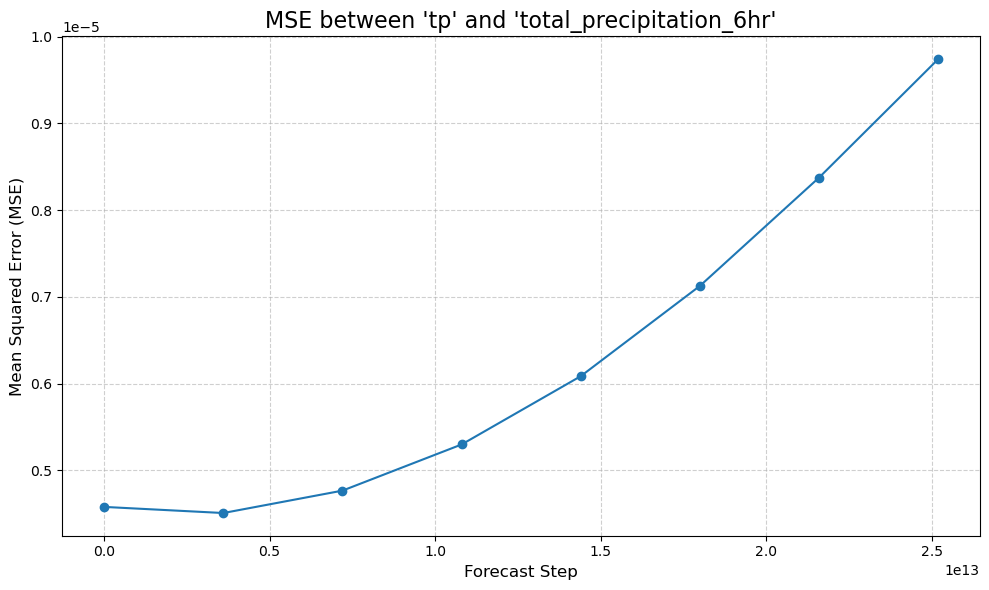

In [ ]:
precip_ds1 = eval_targets['total_precipitation_6hr']

# Select the data at the 6-hour mark.
# We use .sel() to select by coordinate value.
six_hour_forecast = precip_ds1.sel(time=pd.to_timedelta('6 hours'))

# The result has a 'batch' dimension of size 1. We remove it with .squeeze()
# so its dimensions (lat, lon) match the spatial dimensions of ds2.
six_hour_forecast_squeezed = six_hour_forecast.squeeze('batch')

# The second dataset is already our target variable 'tp'
precip_ds2 = regridded_hres

print("\nShape of the 6-hour forecast data from ds1:", six_hour_forecast_squeezed.shape)
print("Shape of the hourly 'tp' data from ds2:", precip_ds2.shape)


# --- 3. Compute the Mean Squared Error (MSE) ---
print("\nStep 3: Calculating Mean Squared Error per step...")

# Xarray will automatically align and broadcast the 'six_hour_forecast_squeezed' array
# across the 'step' dimension of 'precip_ds2' during the subtraction.
squared_error = (six_hour_forecast_squeezed - precip_ds2)**2

# Now, compute the mean over the spatial dimensions ('lat', 'lon') to get
# a single MSE value for each step.
mse_per_step = squared_error.mean(dim=['lat', 'lon'])

print("\nCalculated MSE for each step:")
print(mse_per_step)


# --- 4. Plot the Results ---
print("\nStep 4: Plotting the results...")

# Create the plot
plt.figure(figsize=(10, 6))

# Use xarray's built-in plotting for a quick and easy line plot
mse_per_step.plot.line(marker='o', linestyle='-')

# Customize the plot for clarity
plt.title("MSE between 'tp' and 'total_precipitation_6hr'", fontsize=16)

# The step coordinate is a timedelta; we can format the x-axis for readability
# by getting the total hours from the timedelta coordinate.
x_labels = mse_per_step.step.dt.total_seconds() / 3600
# plt.xticks(mse_per_step.step, labels=[f'{int(h)}h' for h in x_labels])
plt.xlabel("Forecast Step", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
import cartopy.crs as ccrs
import xarray as xr

latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

def plot_difference_with_targets_fine_sims(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg_2.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base_sims(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg_2.png')
    plt.close()

    return (difference)


def plot_diff_hres_imerg_sims(pred_imd, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # if var_name == 'total_precipitation_6hr':
    #     pred_imd = preds_old['tp']
        
    temperature_targets = targets[var_name]

    # imd lat order is reversed

    pred_imd = pred_imd.rename({'latitude': 'lat', 'longitude': 'lon'})
    temp_imd = pred_imd.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step,batch=0).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_imd - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"IMD Prediction vs Ground Truth at Time Step {time_step} for {var_name}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_imd_era5_{var_name}_2.png')
    plt.close()

    return (difference)


  0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_1017688/4066358591.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_{i}_imerg4.nc")
/tmp/ipykernel_1017688/4066358591.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_{i}_imerg4.nc")
100%|██████████| 7/7 [00:01<00:00,  4.45it/s]


[array(1.0033797e-05, dtype=float32), array(1.021905e-05, dtype=float32), array(7.634327e-06, dtype=float32), array(6.816537e-06, dtype=float32), array(8.65921e-06, dtype=float32), array(7.404487e-06, dtype=float32), array(3.1713405e-06, dtype=float32)]
[array(9.86141e-06, dtype=float32), array(1.0115065e-05, dtype=float32), array(7.637193e-06, dtype=float32), array(6.539088e-06, dtype=float32), array(8.536498e-06, dtype=float32), array(7.3626225e-06, dtype=float32), array(3.4359807e-06, dtype=float32)]


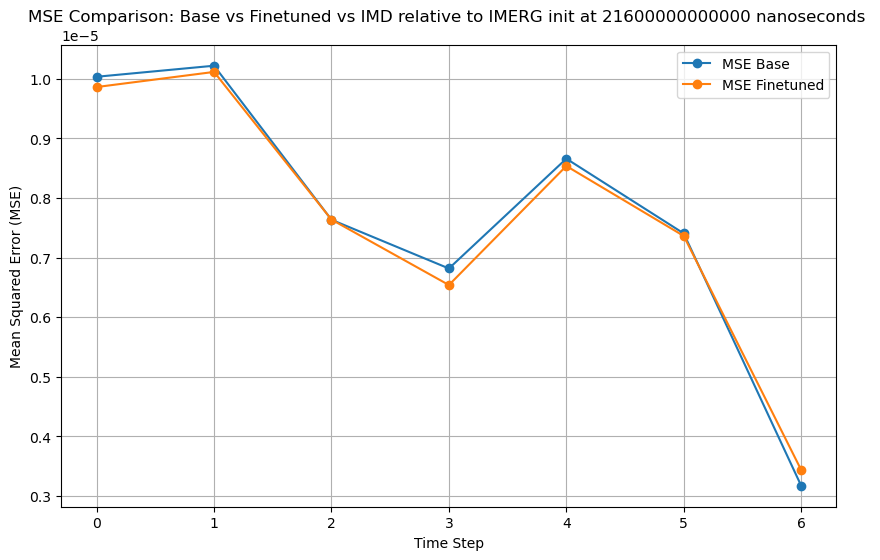

 25%|██▌       | 1/4 [00:09<00:27,  9.04s/it]/tmp/ipykernel_1017688/4066358591.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_{i}_imerg4.nc")
/tmp/ipykernel_1017688/4066358591.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_{i}_imerg4.nc")
100%|██████████| 7/7 [00:01<00:00,  5.72it/s]


[array(8.367737e-06, dtype=float32), array(6.5625504e-06, dtype=float32), array(7.5960097e-06, dtype=float32), array(8.53542e-06, dtype=float32), array(5.964135e-06, dtype=float32), array(6.2080035e-06, dtype=float32), array(9.043581e-06, dtype=float32)]
[array(8.062747e-06, dtype=float32), array(6.4548203e-06, dtype=float32), array(7.762274e-06, dtype=float32), array(7.86616e-06, dtype=float32), array(6.11394e-06, dtype=float32), array(6.6470293e-06, dtype=float32), array(9.235358e-06, dtype=float32)]


<Figure size 640x480 with 0 Axes>

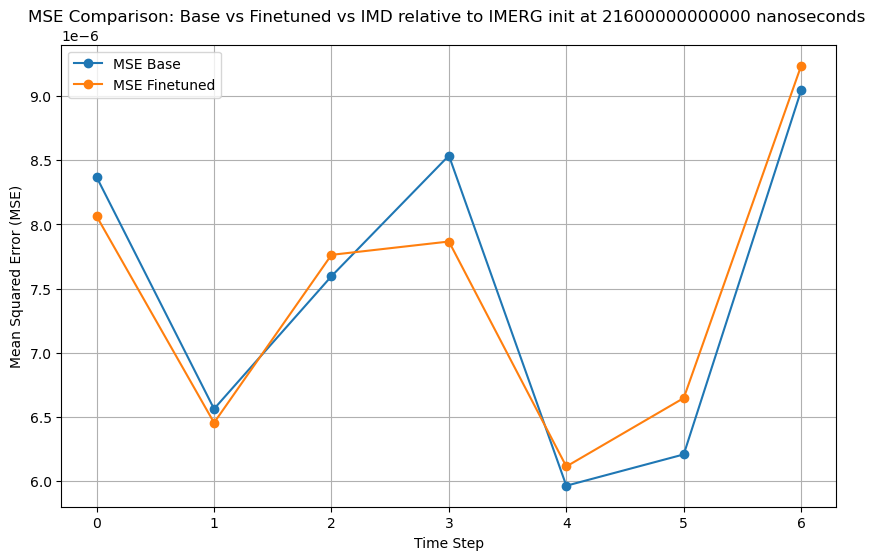

 50%|█████     | 2/4 [00:18<00:18,  9.16s/it]/tmp/ipykernel_1017688/4066358591.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_{i}_imerg4.nc")
/tmp/ipykernel_1017688/4066358591.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_{i}_imerg4.nc")
100%|██████████| 7/7 [00:01<00:00,  5.84it/s]


[array(1.6225436e-05, dtype=float32), array(1.5780395e-05, dtype=float32), array(2.7833987e-05, dtype=float32), array(2.9422295e-05, dtype=float32), array(1.1061955e-05, dtype=float32), array(1.05984345e-05, dtype=float32), array(1.33987305e-05, dtype=float32)]
[array(1.5955173e-05, dtype=float32), array(1.5349722e-05, dtype=float32), array(2.5936393e-05, dtype=float32), array(2.2649774e-05, dtype=float32), array(1.1564224e-05, dtype=float32), array(1.1202443e-05, dtype=float32), array(1.2770541e-05, dtype=float32)]


<Figure size 640x480 with 0 Axes>

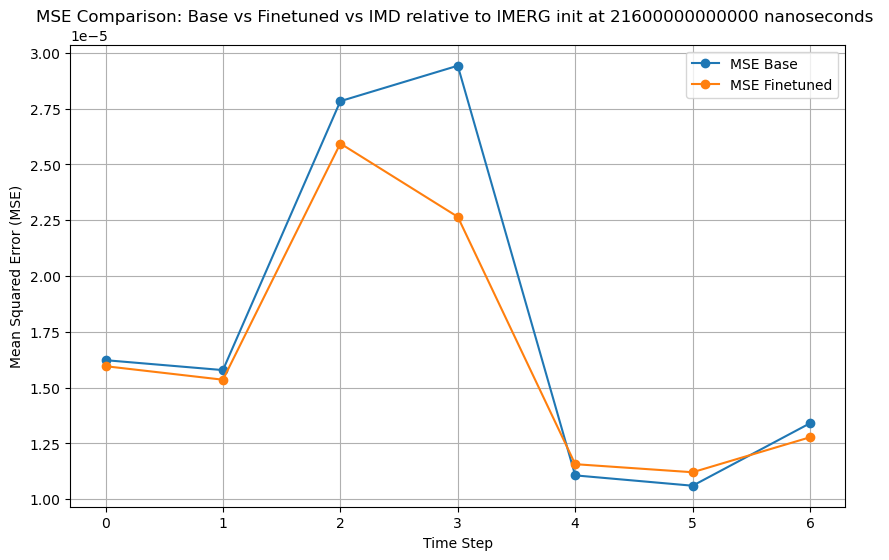

 75%|███████▌  | 3/4 [00:27<00:09,  9.40s/it]/tmp/ipykernel_1017688/4066358591.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_{i}_imerg4.nc")
/tmp/ipykernel_1017688/4066358591.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_{i}_imerg4.nc")
100%|██████████| 7/7 [00:01<00:00,  5.71it/s]


[array(1.9628424e-05, dtype=float32), array(1.219052e-05, dtype=float32), array(1.9188163e-05, dtype=float32), array(1.925561e-05, dtype=float32), array(1.4218504e-05, dtype=float32), array(1.3590297e-05, dtype=float32), array(1.9133793e-05, dtype=float32)]
[array(1.9143416e-05, dtype=float32), array(1.1932329e-05, dtype=float32), array(1.8694003e-05, dtype=float32), array(1.8490578e-05, dtype=float32), array(1.3840682e-05, dtype=float32), array(1.3730787e-05, dtype=float32), array(2.0559903e-05, dtype=float32)]


<Figure size 640x480 with 0 Axes>

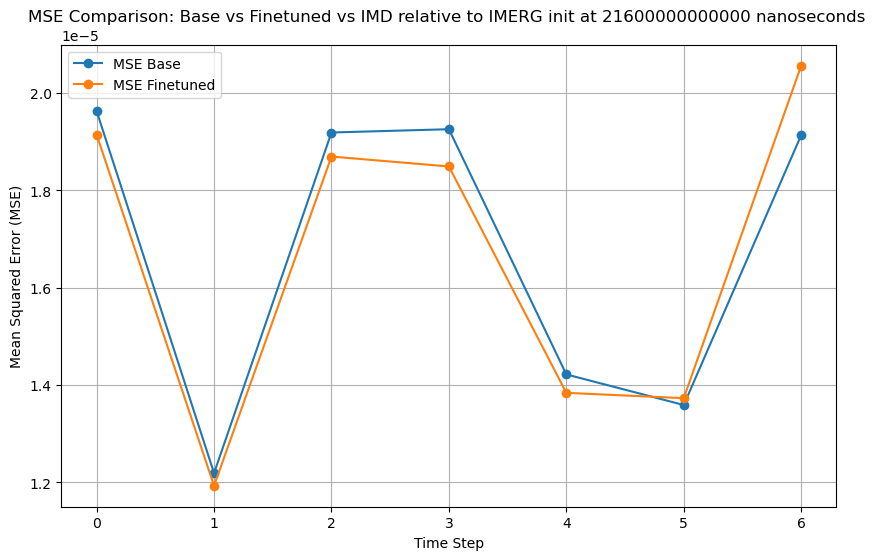

100%|██████████| 4/4 [00:37<00:00,  9.41s/it]


<Figure size 640x480 with 0 Axes>

In [ ]:
import cartopy.crs as ccrs
from datetime import datetime
current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

#iterates over the initialization of the model
for i in tqdm(range(inits)):
    predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_{i}_imerg4.nc")
    predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_{i}_imerg4.nc")
    # hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2015/hres_2015_7_{}_ppt.grib')
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    select_time_evals_copy[i].load(), target_lead_times=slice("6h", "168h"),
    **dataclasses.asdict(task_config))

    # eval_targets = ds_july2015_orig.isel(time=slice(i*7, i*7+7)) # rolling weeks

    init_date = eval_targets.time.values[0]
    init_date = init_date.astype('datetime64[D]')
    # imd_july_2022_temp = imd_july_2022.sel(time=init_date)

    variable_name = 'total_precipitation_6hr'
    
    # Plot differences with ground truth for each time step
    differences_finetuned = []
    differences_base = []
    differences_era5_imd = []
    for time_step in tqdm(range(7)):
        differences_finetuned.append(plot_difference_with_targets_fine_sims(predictions_finetuned,eval_targets,time_step, variable_name))
        differences_base.append(plot_difference_with_targets_base_sims(predictions_old,eval_targets,time_step, variable_name))
        # imd_6h_converted = (imd_july_2022_temp.isel(step=time_step+1)['tp'] - imd_july_2022_temp.isel(step=time_step)['tp'])/1000
        # differences_era5_imd.append(plot_diff_imd_era5_sims(imd_6h_converted,eval_targets,time_step, variable_name))

    # print(differences_finetuned)
    # print(differences_base)

    # print("Finetuned differences: ", differences_finetuned)
    # print("Base differences: ", differences_base)


    # print(differences_base)
    # print(differences_finetuned)
    


    def compute_mse(predictions, targets):
        return ((predictions - targets) ** 2).mean()

    def compute_mse_diffs(diff):
        return (diff ** 2).mean(dim=["lat", "lon"]).values

    # Compute the MSE for each time step and aggregate
    mse_finetuned = []
    mse_base = []
    mse_imd_era5 = []
    for diff_counter in range(len(differences_finetuned)):
        mse_diff_finetuned = compute_mse_diffs(differences_finetuned[diff_counter])
        mse_diff_base = compute_mse_diffs(differences_base[diff_counter])
        # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
        
        mse_finetuned.append(mse_diff_finetuned)
        mse_base.append(mse_diff_base)
        # mse_imd_era5.append(mse_diff_imd_era5)

    # print(mse_base)
    # print()
    # print(mse_finetuned)


    print(mse_base)
    print(mse_finetuned)



    
    # Plot the line chart
    plt.figure(figsize=(10, 6))
    plt.plot(list(range(7)), mse_base, label='MSE Base', marker='o')
    plt.plot(list(range(7)), mse_finetuned, label='MSE Finetuned', marker='o')
    # plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
    # plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

        # Annotate the first and last points for MSE Base
    # plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
    # plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


    # Add labels, title, and legend
    plt.xlabel('Time Step')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to IMERG init at {eval_targets.time.values[0]} ')
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.savefig(f"./final_plots/metrics/mse_2015_imerg_finetune_base_{i}.png")
    plt.show()
    plt.clf()